In [2]:
import sys
from pathlib import Path
proot = Path.cwd().parent
sys.path.append(str(proot))

In [3]:
from SRC.load_data import LoadData
from config.config import RAW_DATA_PATH

loader = LoadData()
df = loader.load(RAW_DATA_PATH)
# print(df.head())
print(df.columns)
print(df.isnull().sum())
print(df.duplicated().sum())

Index(['House_ID', 'City', 'Locality_Tier', 'BHK', 'Bathrooms',
       'Super_Area_sqft', 'Carpet_Area_sqft', 'Floor_No', 'Total_Floors',
       'Property_Age_years', 'Parking', 'Furnishing', 'Lift', 'Gated_Society',
       'Distance_to_Metro_km', 'Distance_to_CityCenter_km', 'Nearby_School_km',
       'Nearby_Hospital_km', 'Crime_Rate_Index', 'Market_Price_INR',
       'Price_per_sqft_INR'],
      dtype='object')
House_ID                     0
City                         0
Locality_Tier                0
BHK                          0
Bathrooms                    0
Super_Area_sqft              0
Carpet_Area_sqft             0
Floor_No                     0
Total_Floors                 0
Property_Age_years           0
Parking                      0
Furnishing                   0
Lift                         0
Gated_Society                0
Distance_to_Metro_km         0
Distance_to_CityCenter_km    0
Nearby_School_km             0
Nearby_Hospital_km           0
Crime_Rate_Index        

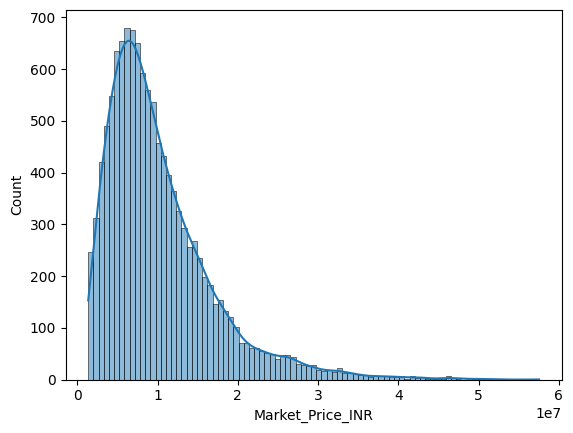

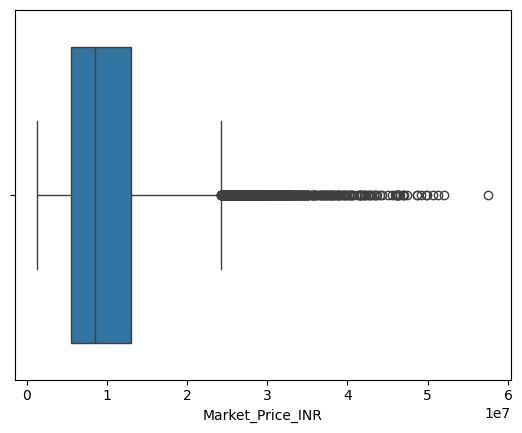

In [4]:
# Target variable analysis
import seaborn as sns
import matplotlib.pyplot as plt
df["Market_Price_INR"].describe()
sns.histplot(df["Market_Price_INR"], kde=True)
plt.show()

sns.boxplot(x=df["Market_Price_INR"])
plt.show()

Market_price_INR contains a significant number of high value outliers.
The distribustion is positively skewed with a long right tails.
Mpost properties fall within the lower and mid price ranges, while a small number of luxury properties contributes to extreme values.
Outliers will be investigated further before deciding whether to remove or transform them.

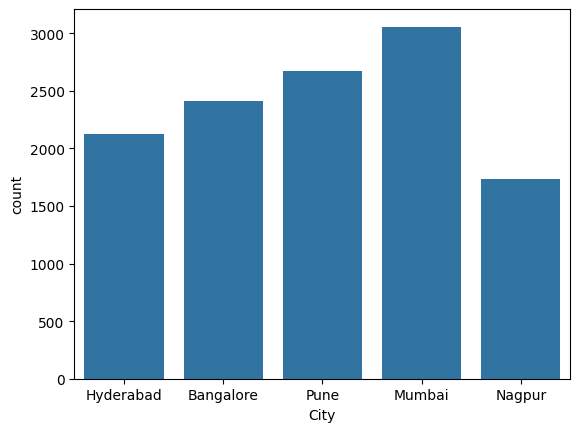

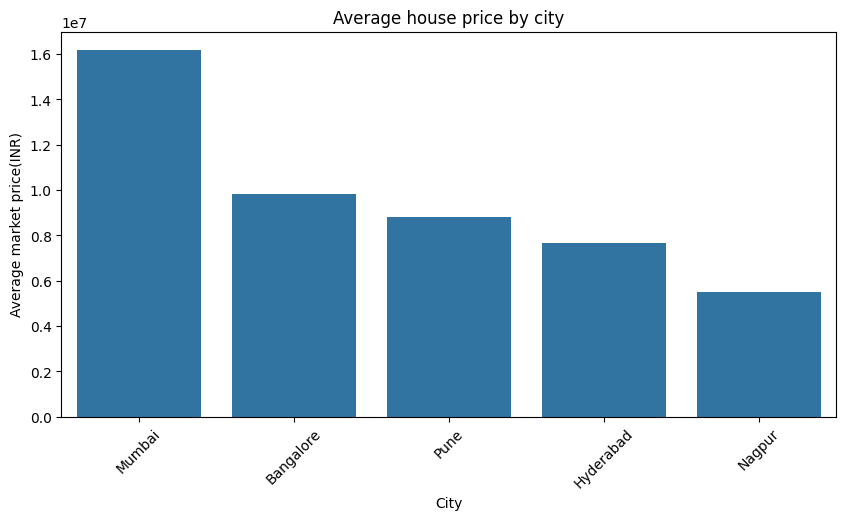

In [5]:
# Categorical feature analysis
import matplotlib.pyplot  as plt
sns.countplot(x="City", data=df)
city_price = df.groupby("City")["Market_Price_INR"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(
    x = city_price.index,
    y=city_price.values
)
plt.title("Average house price by city")
plt.xlabel("City")
plt.ylabel("Average market price(INR)")
plt.xticks(rotation=45)
plt.show()



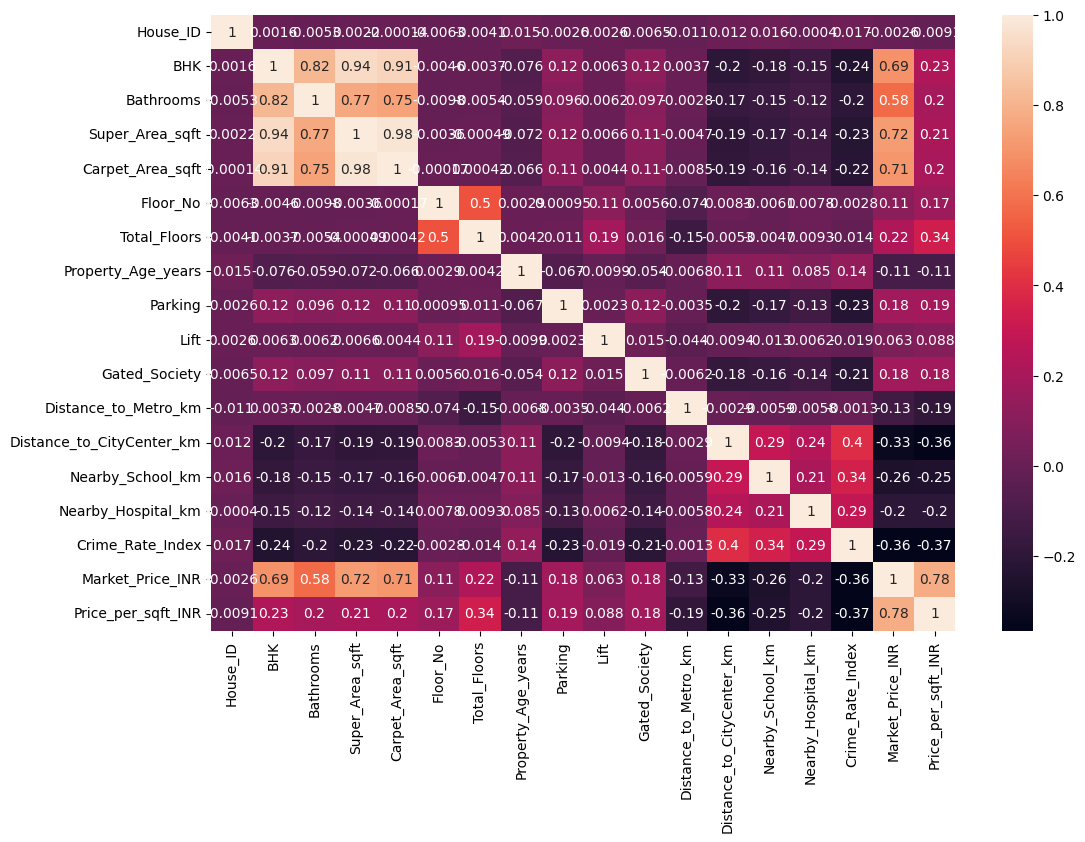

In [6]:
# Correlation analysis
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True)
plt.show()

In [7]:
print(df["Market_Price_INR"].skew())
print(df["Market_Price_INR"].kurtosis())

1.7139944822958895
4.317224889571535


Target variable(Market_Price_INR) is highly positively skewed(skewness = 1.71)
The kurtosis value of 4.31 indicates the presence of heavy tails and extreme observation.
Histogram and boxplot analysis are confirm the existence of several high-value properties acting as outliers.
A target transformation such as log transformation may improve the model performance

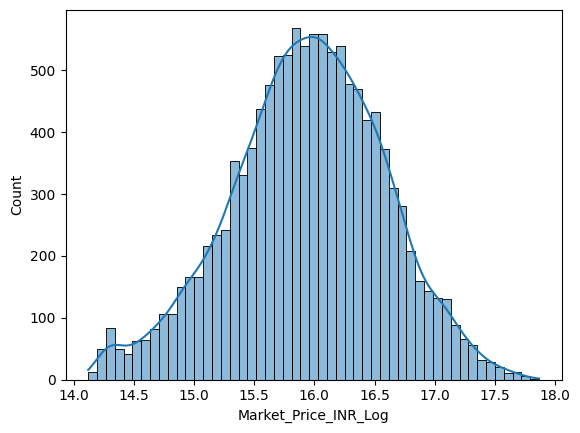

-0.18885434861928982


In [8]:
import numpy as np
df["Market_Price_INR_Log"] = np.log1p(df["Market_Price_INR"])
sns.histplot(df["Market_Price_INR_Log"], kde=True)
plt.show()

print(df["Market_Price_INR_Log"].skew())

In [9]:
drop_col= ["House_ID","Carpet_Area_sqft"]
df_train = df.drop(columns=drop_col)
processed_path = Path("../data/processed/house_price_processed.csv")
processed_path.parent.mkdir(parents=True,exist_ok=True)

df_train.to_csv(processed_path, index=False)